<a href="https://colab.research.google.com/github/HeshanNavindu-7/oilspill-reseach/blob/main/Final_LSTM_model__june_1st_week.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
from datetime import datetime, timezone, timedelta
from getpass import getpass

import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

CSV_PATH = "/content/drive/MyDrive/Research/Trajectory/cleaned_trajectory_data_final_trajectory_dataset (1).csv"

df = pd.read_csv(CSV_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))
display(df.head())

Rows: 3000
Columns: 17


,spill_id,time_step,scene_lat,scene_lon,wind_u,wind_v,current_u,current_v,wave_height,area_pixels,next_lat,next_lon,delta_lat,delta_lon,slick_type_Emulsion,slick_type_Oil,slick_type_Sheen
0,SPILL_EVENT_0,0,7.200000,79.840000,-3.555989,-3.545089,0.095588,0.049569,0.276454,380310.365411,7.198160,79.839641,-0.001840,-0.000359,False,True,False
1,SPILL_EVENT_0,1,7.198160,79.839641,-3.249740,-3.276766,0.083557,0.013338,0.181205,366599.943252,7.195407,79.839189,-0.002753,-0.000452,False,True,False
2,SPILL_EVENT_0,2,7.195407,79.839189,-3.146684,-3.485210,0.083717,0.025340,0.340345,383824.987256,7.192841,79.838843,-0.002567,-0.000346,False,True,False
3,SPILL_EVENT_0,3,7.192841,79.838843,-3.542901,-3.560106,0.078550,0.040686,0.428336,365009.418877,7.190699,79.837944,-0.002142,-0.000899,False,True,False
4,SPILL_EVENT_0,4,7.190699,79.837944,-3.442513,-3.651597,0.086781,0.057986,0.415847,373149.542465,7.189028,79.837410,-0.001671,-0.000534,False,True,False


In [3]:
feature_columns = [
    "centroid_x",
    "centroid_y",
    "area_pixels",
    "area_ratio",

    "scene_lat",
    "scene_lon",

    "wind_speed",
    "wind_direction",
    "current_speed",
    "current_direction",
    "wave_height",
    "wave_direction",
    "wave_period",
    "swell_height",
    "swell_direction",
    "swell_period",

    "wind_u",
    "wind_v",
    "current_u",
    "current_v",
    "wave_u",
    "wave_v",
    "swell_u",
    "swell_v"
]

target_columns = ["next_lat", "next_lon"]

feature_columns = [col for col in feature_columns if col in df.columns]

model_df = df.copy()
model_df = model_df.dropna(subset=target_columns)
model_df[feature_columns] = model_df[feature_columns].fillna(0)

print("Final rows:", len(model_df))
print("Feature count:", len(feature_columns))
display(model_df[feature_columns + target_columns].head())

Final rows: 3000
Feature count: 8


,area_pixels,scene_lat,scene_lon,wave_height,wind_u,wind_v,current_u,current_v,next_lat,next_lon
0,380310.365411,7.200000,79.840000,0.276454,-3.555989,-3.545089,0.095588,0.049569,7.198160,79.839641
1,366599.943252,7.198160,79.839641,0.181205,-3.249740,-3.276766,0.083557,0.013338,7.195407,79.839189
2,383824.987256,7.195407,79.839189,0.340345,-3.146684,-3.485210,0.083717,0.025340,7.192841,79.838843
3,365009.418877,7.192841,79.838843,0.428336,-3.542901,-3.560106,0.078550,0.040686,7.190699,79.837944
4,373149.542465,7.190699,79.837944,0.415847,-3.442513,-3.651597,0.086781,0.057986,7.189028,79.837410


In [4]:
from sklearn.preprocessing import MinMaxScaler

X = model_df[feature_columns].values
y = model_df[target_columns].values

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

print("X shape:", X_scaled.shape)
print("y shape:", y_scaled.shape)

X shape: (3000, 8)
y shape: (3000, 2)


In [7]:
from sklearn.model_selection import GroupShuffleSplit

groups = model_df["spill_id"].values

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X_scaled, y_scaled, groups=groups))

X_train = X_scaled[train_idx]
X_test = X_scaled[test_idx]

y_train = y_scaled[train_idx]
y_test = y_scaled[test_idx]

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train images:", train_df["spill_id"].nunique())
print("Test images:", test_df["spill_id"].nunique())

Train rows: 2250
Test rows: 750
Train images: 150
Test images: 50


In [8]:
# LSTM input shape should be: samples, timesteps, features
# Since each row is one scenario, use timestep = 1

X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)

X_train_lstm shape: (2250, 1, 8)
X_test_lstm shape: (750, 1, 8)


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

lstm_model = Sequential([
    LSTM(
        64,
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]),
        return_sequences=False
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(2)
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,330 (83.32 KB)

 Trainable params: 21,330 (83.32 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0195 - mae: 0.0914 - val_loss: 0.0025 - val_mae: 0.0366
Epoch 2/200
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0035 - mae: 0.0451 - val_loss: 0.0018 - val_mae: 0.0330
Epoch 3/200
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0026 - mae: 0.0392 - val_loss: 0.0011 - val_mae: 0.0242
Epoch 4/200
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0018 - mae: 0.0329 - val_loss: 5.9139e-04 - val_mae: 0.0181
Epoch 5/200
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0015 - mae: 0.0301 - val_loss: 6.8767e-04 - val_mae: 0.0228
Epoch 6/200
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0012 - mae: 0.0264 - val_loss: 6.5610e-04 - val_mae: 0.0230
Epoch 7/200
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.6238e-04 - mae: 0.0243 - val_loss: 1.3357e-04 - val_mae: 0.0079
Epoch 8/200
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.7738e-04 - mae: 0.0228 - val_loss: 4.3962e-04 - val_mae: 0.0186
Epoch 9/200
225/225 

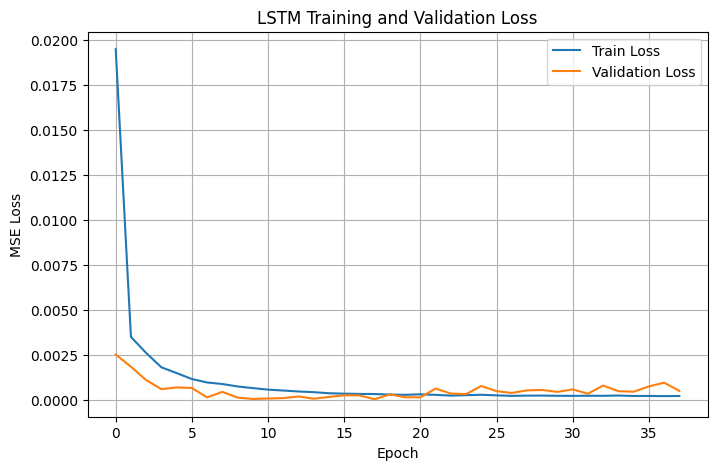

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

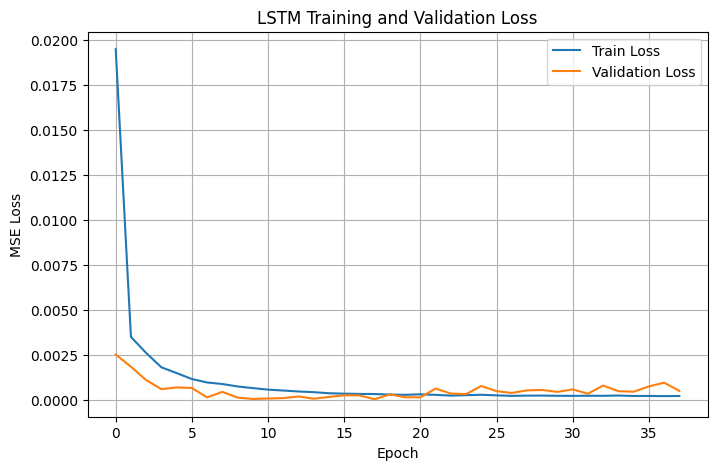

Saved: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/lstm_training_loss.png


In [13]:
from pathlib import Path

LSTM_LOSS_PLOT = "/content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/lstm_training_loss.png"

# Create the directory if it does not exist
Path(LSTM_LOSS_PLOT).parent.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(LSTM_LOSS_PLOT, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", LSTM_LOSS_PLOT)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred_scaled = lstm_model.predict(X_test_lstm)

# Convert back to actual latitude/longitude scale
pred_lstm = scaler_y.inverse_transform(pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

lstm_mae = mean_absolute_error(y_test_actual, pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, pred_lstm))
lstm_r2 = r2_score(y_test_actual, pred_lstm)

print("LSTM Trajectory Model Evaluation")
print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("R2  :", lstm_r2)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
LSTM Trajectory Model Evaluation
MAE : 0.0016757745907166513
RMSE: 0.0021463954452646834
R2  : 0.9975905058836536


In [15]:
import math

def haversine_distance_m(lat1, lon1, lat2, lon2):
    R = 6371000

    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    )

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c


lstm_distance_errors = []

for actual, predicted in zip(y_test_actual, pred_lstm):
    actual_lat, actual_lon = actual
    pred_lat, pred_lon = predicted

    dist_error = haversine_distance_m(
        actual_lat,
        actual_lon,
        pred_lat,
        pred_lon
    )

    lstm_distance_errors.append(dist_error)

lstm_distance_errors = np.array(lstm_distance_errors)

print("LSTM Distance Error Results")
print("Mean distance error:", lstm_distance_errors.mean(), "meters")
print("RMSE distance error:", np.sqrt(np.mean(lstm_distance_errors ** 2)), "meters")
print("Min distance error:", lstm_distance_errors.min(), "meters")
print("Max distance error:", lstm_distance_errors.max(), "meters")

LSTM Distance Error Results
Mean distance error: 287.22997374553466 meters
RMSE distance error: 335.8172766814524 meters
Min distance error: 9.53657089739005 meters
Max distance error: 1216.500678779792 meters


In [17]:
lstm_comparison_df = test_df[[
    "spill_id",
    "time_step",
    "scene_lat",
    "scene_lon",
    "next_lat",
    "next_lon"
]].copy()

lstm_comparison_df["lstm_pred_next_lat"] = pred_lstm[:, 0]
lstm_comparison_df["lstm_pred_next_lon"] = pred_lstm[:, 1]

lstm_comparison_df["lstm_lat_error"] = abs(
    lstm_comparison_df["next_lat"] - lstm_comparison_df["lstm_pred_next_lat"]
)

lstm_comparison_df["lstm_lon_error"] = abs(
    lstm_comparison_df["next_lon"] - lstm_comparison_df["lstm_pred_next_lon"]
)

lstm_comparison_df["lstm_distance_error_m"] = lstm_distance_errors

display(lstm_comparison_df)

,spill_id,time_step,scene_lat,scene_lon,next_lat,next_lon,lstm_pred_next_lat,lstm_pred_next_lon,lstm_lat_error,lstm_lon_error,lstm_distance_error_m
180,SPILL_EVENT_12,0,7.200000,79.840000,7.206051,79.837613,7.207124,79.840889,0.001073,0.003276,380.599520
181,SPILL_EVENT_12,1,7.206051,79.837613,7.211280,79.836237,7.211759,79.838997,0.000479,0.002760,309.142804
182,SPILL_EVENT_12,2,7.211280,79.836237,7.217635,79.833591,7.217849,79.836189,0.000214,0.002598,287.623360
183,SPILL_EVENT_12,3,7.217635,79.833591,7.223506,79.831734,7.223226,79.834183,0.000280,0.002448,271.868431
184,SPILL_EVENT_12,4,7.223506,79.831734,7.229362,79.829810,7.228664,79.831848,0.000698,0.002038,237.804968
...,...,...,...,...,...,...,...,...,...,...,...
2890,SPILL_EVENT_192,10,7.224354,79.801758,7.226259,79.797591,7.224987,79.794640,0.001272,0.002952,355.016640
2891,SPILL_EVENT_192,11,7.226259,79.797591,7.228550,79.794085,7.227310,79.791313,0.001240,0.002772,335.385486
2892,SPILL_EVENT_192,12,7.228550,79.794085,7.230957,79.790882,7.229680,79.788162,0.001277,0.002720,331.896497
2893,SPILL_EVENT_192,13,7.230957,79.790882,7.233821,79.787164,7.232354,79.783676,0.001467,0.003488,417.954287


In [18]:
rf_mae = 0.03859745776499872
rf_rmse = 0.05135330872935758
rf_r2 = 0.52163067044691
rf_mean_distance_error = 6657.078951318603
rf_rmse_distance_error = 7952.814003052021

model_comparison_df = pd.DataFrame([
    {
        "Model": "Random Forest Baseline",
        "MAE_degrees": rf_mae,
        "RMSE_degrees": rf_rmse,
        "R2": rf_r2,
        "Mean_Distance_Error_km": rf_mean_distance_error / 1000,
        "RMSE_Distance_Error_km": rf_rmse_distance_error / 1000
    },
    {
        "Model": "LSTM Prototype",
        "MAE_degrees": lstm_mae,
        "RMSE_degrees": lstm_rmse,
        "R2": lstm_r2,
        "Mean_Distance_Error_km": lstm_distance_errors.mean() / 1000,
        "RMSE_Distance_Error_km": np.sqrt(np.mean(lstm_distance_errors ** 2)) / 1000
    }
])

display(model_comparison_df)

,Model,MAE_degrees,RMSE_degrees,R2,Mean_Distance_Error_km,RMSE_Distance_Error_km
0,Random Forest Baseline,0.038597,0.051353,0.521631,6.657079,7.952814
1,LSTM Prototype,0.001676,0.002146,0.997591,0.287230,0.335817
